<a href="https://colab.research.google.com/github/Maee127/Adversarial-Notebooks/blob/master/%237/Note07_Bayesian_Uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =============================================================
# Adversarial Attacks Series — Note 07
# Knowing the Weights: Four Bayesian Lenses on Uncertainty
# =============================================================
#
# Series:  Humble Model / Bayesian Uncertainty
# Dataset: CIFAR-10
# Model:   CNN (same backbone as Essay #6)
#
# Notebook structure:
#   Part A: Imports and Setup
#   Part B: Dataset Loading (CIFAR-10, held-out split)
#   Part C: Shared Backbone Architecture
#   Part D: Baseline Model (load or train)
#   Part E: Method 1 — Monte Carlo Dropout
#   Part F: Method 2 — Deep Ensembles
#   Part G: Method 3 — SWAG
#   Part H: Method 4 — Variational Inference
#   Part I: Evaluation Protocol
#   Part J: Head-to-Head Comparison
#   Part K: Summary and Outputs
# =============================================================

In [1]:
# -------------------------------------------------------------
# Part A: Imports and Setup
# -------------------------------------------------------------

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os
from tqdm import tqdm
import random
import json

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

Using device: cuda


In [2]:
# -------------------------------------------------------------
# Part B: Dataset Loading (CIFAR-10) — with held-out split
# -------------------------------------------------------------

cifar_transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

cifar_transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=cifar_transform_train)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=cifar_transform_test)

# Held-out split: 20% calibration, 80% evaluation
calib_size = int(0.2 * len(test_dataset))
eval_size = len(test_dataset) - calib_size
calib_dataset, eval_dataset = random_split(test_dataset, [calib_size, eval_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
calib_loader = DataLoader(calib_dataset, batch_size=64, shuffle=False, num_workers=0)
eval_loader = DataLoader(eval_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"Training samples: {len(train_dataset):,}")
print(f"Calibration samples: {len(calib_dataset):,}")
print(f"Evaluation samples: {len(eval_dataset):,}")

# Per-channel valid normalized range
CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(1, 3, 1, 1)
CIFAR_STD = torch.tensor([0.2023, 0.1994, 0.2010]).view(1, 3, 1, 1)
CIFAR_MIN = ((0 - CIFAR_MEAN) / CIFAR_STD).to(DEVICE)
CIFAR_MAX = ((1 - CIFAR_MEAN) / CIFAR_STD).to(DEVICE)

def clamp_valid(x):
    return torch.max(torch.min(x, CIFAR_MAX), CIFAR_MIN)

100%|██████████| 170M/170M [05:46<00:00, 492kB/s]


Training samples: 50,000
Calibration samples: 2,000
Evaluation samples: 8,000


In [3]:

# -------------------------------------------------------------
# Part C: Shared Backbone Architecture
# -------------------------------------------------------------

class BackboneCNN(nn.Module):
    """Shared backbone for all Bayesian methods."""
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        return x

class StandardCNN(nn.Module):
    """Standard CNN for baseline."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = BackboneCNN()
        self.fc_out = nn.Linear(256, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.fc_out(features)

In [4]:
# -------------------------------------------------------------
# Part D: Baseline Model (load or train)
# -------------------------------------------------------------

def train_model(model, train_loader, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch} — avg loss: {avg_loss:.4f}")
    return model

def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            _, preds = outputs.max(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

baseline_model = StandardCNN().to(DEVICE)

if os.path.exists('checkpoint_baseline_cifar10.pth'):
    checkpoint = torch.load('checkpoint_baseline_cifar10.pth', map_location=DEVICE)
    baseline_model.load_state_dict(checkpoint['model_state_dict'])
    print("Loaded baseline model from checkpoint")
else:
    print("Training baseline model from scratch...")
    baseline_model = train_model(baseline_model, train_loader, epochs=20)
    torch.save({'model_state_dict': baseline_model.state_dict()}, 'checkpoint_baseline_cifar10.pth')
    print("Saved baseline model checkpoint")

clean_acc = evaluate_accuracy(baseline_model, eval_loader)
print(f"Baseline clean test accuracy: {clean_acc:.2f}%")

Training baseline model from scratch...


Epoch 0: 100%|██████████| 782/782 [00:24<00:00, 32.21it/s]


Epoch 0 — avg loss: 1.5793


Epoch 1: 100%|██████████| 782/782 [00:23<00:00, 33.38it/s]


Epoch 1 — avg loss: 1.2164


...

Epoch 17 — avg loss: 0.6104


Epoch 18: 100%|██████████| 782/782 [00:22<00:00, 34.30it/s]


Epoch 18 — avg loss: 0.5988


Epoch 19: 100%|██████████| 782/782 [00:23<00:00, 33.71it/s]


Epoch 19 — avg loss: 0.5925
Saved baseline model checkpoint
Baseline clean test accuracy: 78.61%


In [5]:
# -------------------------------------------------------------
# Part E: Method 1 — Monte Carlo Dropout
# -------------------------------------------------------------

class DropoutCNN(nn.Module):
    """CNN with dropout in the backbone for MC Dropout inference."""
    def __init__(self, num_classes=10, dropout_rate=0.3):
        super().__init__()
        self.backbone = BackboneCNN()
        self.fc_out = nn.Linear(256, num_classes)
        # Replace the backbone's dropout with the desired rate
        self.backbone.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        features = self.backbone(x)
        return self.fc_out(features)

mc_model = DropoutCNN(dropout_rate=0.3).to(DEVICE)

if os.path.exists('checkpoint_mc_dropout.pth'):
    checkpoint = torch.load('checkpoint_mc_dropout.pth', map_location=DEVICE)
    mc_model.load_state_dict(checkpoint['model_state_dict'])
    print("Loaded MC Dropout model from checkpoint")
else:
    print("Training MC Dropout model...")
    mc_model = train_model(mc_model, train_loader, epochs=20)
    torch.save({'model_state_dict': mc_model.state_dict()}, 'checkpoint_mc_dropout.pth')
    print("Saved MC Dropout model checkpoint")

def mc_dropout_predict(model, image, num_passes=50):
    """Run MC Dropout inference."""
    model.train()  # enable dropout
    predictions = []
    for _ in range(num_passes):
        with torch.no_grad():
            pred = torch.softmax(model(image), dim=1)
            predictions.append(pred)
    model.eval()
    predictions = torch.stack(predictions)  # [N, batch, classes]
    mean_pred = predictions.mean(dim=0)
    variance = predictions.var(dim=0)
    return mean_pred, variance

# Sanity check
test_image, test_label = eval_dataset[0]
test_image = test_image.unsqueeze(0).to(DEVICE)
mean_pred, variance = mc_dropout_predict(mc_model, test_image, num_passes=50)
print(f"\nMC Dropout sanity check:")
print(f"  True label: {test_label}")
print(f"  Predicted: {mean_pred.argmax().item()}")
print(f"  Confidence: {mean_pred.max().item():.4f}")
print(f"  Variance (max): {variance.max().item():.6f}")

Training MC Dropout model...


Epoch 0: 100%|██████████| 782/782 [00:22<00:00, 34.27it/s]


Epoch 0 — avg loss: 1.5477


Epoch 1: 100%|██████████| 782/782 [00:23<00:00, 33.84it/s]


Epoch 1 — avg loss: 1.1680


...

Epoch 17 — avg loss: 0.5686


Epoch 18: 100%|██████████| 782/782 [00:24<00:00, 32.31it/s]


Epoch 18 — avg loss: 0.5563


Epoch 19: 100%|██████████| 782/782 [00:22<00:00, 34.02it/s]


Epoch 19 — avg loss: 0.5474
Saved MC Dropout model checkpoint

MC Dropout sanity check:
  True label: 2
  Predicted: 2
  Confidence: 0.8413
  Variance (max): 0.016266


In [6]:
# -------------------------------------------------------------
# Part F: Method 2 — Deep Ensembles
# -------------------------------------------------------------

NUM_ENSEMBLE = 5
ensemble_models = []

for i in range(NUM_ENSEMBLE):
    ckpt_path = f'checkpoint_ensemble_{i}.pth'
    model = StandardCNN().to(DEVICE)
    if os.path.exists(ckpt_path):
        checkpoint = torch.load(ckpt_path, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        model.eval()
        ensemble_models.append(model)
        print(f"Loaded ensemble member {i}")
    else:
        print(f"Training ensemble member {i}...")
        set_seed(i)
        model = train_model(model, train_loader, epochs=20)
        torch.save({'model_state_dict': model.state_dict()}, ckpt_path)
        ensemble_models.append(model)
        print(f"Saved ensemble member {i}")

def ensemble_predict(models, image):
    """Run ensemble inference."""
    predictions = []
    for model in models:
        model.eval()
        with torch.no_grad():
            pred = torch.softmax(model(image), dim=1)
            predictions.append(pred)
    predictions = torch.stack(predictions)
    mean_pred = predictions.mean(dim=0)
    variance = predictions.var(dim=0)
    return mean_pred, variance

# Sanity check
mean_pred_ens, variance_ens = ensemble_predict(ensemble_models, test_image)
print(f"\nDeep Ensemble sanity check:")
print(f"  True label: {test_label}")
print(f"  Predicted: {mean_pred_ens.argmax().item()}")
print(f"  Confidence: {mean_pred_ens.max().item():.4f}")
print(f"  Variance (max): {variance_ens.max().item():.6f}")

Training ensemble member 0...


Epoch 0: 100%|██████████| 782/782 [00:22<00:00, 34.28it/s]


Epoch 0 — avg loss: 1.5708


Epoch 1: 100%|██████████| 782/782 [00:22<00:00, 34.82it/s]


Epoch 1 — avg loss: 1.1911


...

Epoch 17 — avg loss: 0.5715


Epoch 18: 100%|██████████| 782/782 [00:22<00:00, 34.11it/s]


Epoch 18 — avg loss: 0.5626


Epoch 19: 100%|██████████| 782/782 [00:22<00:00, 34.21it/s]

Epoch 19 — avg loss: 0.5570
Saved ensemble member 4

Deep Ensemble sanity check:
  True label: 2
  Predicted: 5
  Confidence: 0.3028
  Variance (max): 0.061952


In [7]:
# -------------------------------------------------------------
# Part G: Method 3 — SWAG
# -------------------------------------------------------------

class SWAG:
    """
    Stochastic Weight Averaging — Gaussian.
    Fits a Gaussian to the trajectory of SGD iterates.
    """
    def __init__(self, model, max_models=20, num_samples=30):
        self.model = model
        self.max_models = max_models
        self.num_samples = num_samples
        self.means = None
        self.sq_means = None
        self.deviations = None
        self.num_collected = 0

    def collect(self):
        """Collect current weights."""
        params = [p.data.clone().flatten() for p in self.model.parameters()]
        flat_params = torch.cat(params)
        if self.means is None:
            self.means = flat_params.clone()
            self.sq_means = flat_params.pow(2).clone()
        else:
            self.means = (self.means * self.num_collected + flat_params) / (self.num_collected + 1)
            self.sq_means = (self.sq_means * self.num_collected + flat_params.pow(2)) / (self.num_collected + 1)
        self.num_collected += 1

    def fit(self):
        """Fit the Gaussian: compute mean and covariance (diagonal approximation)."""
        self.means = self.means / 1.0  # already averaged
        variance = self.sq_means - self.means.pow(2)
        self.deviations = torch.sqrt(torch.clamp(variance, min=1e-6))

    def sample(self, num_samples=None):
        """Sample weights from the fitted Gaussian."""
        if num_samples is None:
            num_samples = self.num_samples
        samples = []
        for _ in range(num_samples):
            sampled = self.means + self.deviations * torch.randn_like(self.means)
            samples.append(sampled)
        return samples

    def load_sample(self, sampled_flat):
        """Load a flattened sample back into the model."""
        offset = 0
        for p in self.model.parameters():
            numel = p.numel()
            p.data.copy_(sampled_flat[offset:offset+numel].view(p.shape))
            offset += numel

# Train SWAG model
swag_model = StandardCNN().to(DEVICE)
swag = SWAG(swag_model, max_models=20, num_samples=30)

if os.path.exists('checkpoint_swag.pth'):
    checkpoint = torch.load('checkpoint_swag.pth', map_location=DEVICE)
    swag_model.load_state_dict(checkpoint['model_state_dict'])
    swag.means = checkpoint['swag_means']
    swag.deviations = checkpoint['swag_deviations']
    print("Loaded SWAG model from checkpoint")
else:
    print("Training SWAG model...")
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(swag_model.parameters(), lr=0.001)
    for epoch in range(20):
        swag_model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = swag_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch} — avg loss: {running_loss/len(train_loader):.4f}")
        # Collect weights at the end of each epoch
        swag.collect()
    swag.fit()
    torch.save({
        'model_state_dict': swag_model.state_dict(),
        'swag_means': swag.means,
        'swag_deviations': swag.deviations,
    }, 'checkpoint_swag.pth')
    print("Saved SWAG model checkpoint")

def swag_predict(swag, image, num_samples=30):
    """Run SWAG inference by sampling weights."""
    predictions = []
    for _ in range(num_samples):
        sampled = swag.means + swag.deviations * torch.randn_like(swag.means)
        swag.load_sample(sampled)
        swag.model.eval()
        with torch.no_grad():
            pred = torch.softmax(swag.model(image), dim=1)
            predictions.append(pred)
    # Restore mean weights
    swag.load_sample(swag.means)
    predictions = torch.stack(predictions)
    mean_pred = predictions.mean(dim=0)
    variance = predictions.var(dim=0)
    return mean_pred, variance

# Sanity check
mean_pred_swag, variance_swag = swag_predict(swag, test_image, num_samples=30)
print(f"\nSWAG sanity check:")
print(f"  True label: {test_label}")
print(f"  Predicted: {mean_pred_swag.argmax().item()}")
print(f"  Confidence: {mean_pred_swag.max().item():.4f}")
print(f"  Variance (max): {variance_swag.max().item():.6f}")

Training SWAG model...


Epoch 0: 100%|██████████| 782/782 [00:22<00:00, 34.92it/s]


Epoch 0 — avg loss: 1.5787


Epoch 1: 100%|██████████| 782/782 [00:22<00:00, 35.32it/s]


Epoch 1 — avg loss: 1.2203


...

Epoch 17 — avg loss: 0.6077


Epoch 18: 100%|██████████| 782/782 [00:22<00:00, 34.70it/s]


Epoch 18 — avg loss: 0.5989


Epoch 19: 100%|██████████| 782/782 [00:22<00:00, 34.11it/s]


Epoch 19 — avg loss: 0.5954
Saved SWAG model checkpoint

SWAG sanity check:
  True label: 2
  Predicted: 4
  Confidence: 0.4635
  Variance (max): 0.062248


In [8]:


# -------------------------------------------------------------
# Part H: Method 4 — Variational Inference (Bayes by Backprop)
# -------------------------------------------------------------

class BayesianLinear(nn.Module):
    """Bayesian linear layer with mean and log-variance parameters."""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.weight_mean = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.weight_logvar = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.bias_mean = nn.Parameter(torch.zeros(out_features))
        self.bias_logvar = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        weight_std = torch.exp(0.5 * self.weight_logvar)
        bias_std = torch.exp(0.5 * self.bias_logvar)
        weight = self.weight_mean + weight_std * torch.randn_like(weight_std)
        bias = self.bias_mean + bias_std * torch.randn_like(bias_std)
        return F.linear(x, weight, bias)

    def kl_divergence(self):
        """KL divergence from the variational posterior to the prior N(0, I)."""
        weight_kl = 0.5 * (self.weight_mean.pow(2) + self.weight_logvar.exp() - self.weight_logvar - 1).sum()
        bias_kl = 0.5 * (self.bias_mean.pow(2) + self.bias_logvar.exp() - self.bias_logvar - 1).sum()
        return weight_kl + bias_kl

class BayesianCNN(nn.Module):
    """CNN with Bayesian layers for Variational Inference."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.fc1 = BayesianLinear(128 * 4 * 4, 256)
        self.fc2 = BayesianLinear(256, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

    def kl_divergence(self):
        return self.fc1.kl_divergence() + self.fc2.kl_divergence()

vi_model = BayesianCNN().to(DEVICE)

if os.path.exists('checkpoint_vi.pth'):
    checkpoint = torch.load('checkpoint_vi.pth', map_location=DEVICE)
    vi_model.load_state_dict(checkpoint['model_state_dict'])
    print("Loaded VI model from checkpoint")
else:
    print("Training VI model...")
    optimizer = optim.Adam(vi_model.parameters(), lr=0.001)
    num_batches = len(train_loader)
    for epoch in range(20):
        vi_model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = vi_model(images)
            ce_loss = F.cross_entropy(outputs, labels)
            kl_loss = vi_model.kl_divergence() / num_batches
            loss = ce_loss + kl_loss * 0.001  # scale the KL term
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch} — avg loss: {running_loss/len(train_loader):.4f}")
    torch.save({'model_state_dict': vi_model.state_dict()}, 'checkpoint_vi.pth')
    print("Saved VI model checkpoint")

def vi_predict(model, image, num_samples=30):
    """Run VI inference by sampling weights."""
    model.eval()
    predictions = []
    for _ in range(num_samples):
        with torch.no_grad():
            pred = torch.softmax(model(image), dim=1)
            predictions.append(pred)
    predictions = torch.stack(predictions)
    mean_pred = predictions.mean(dim=0)
    variance = predictions.var(dim=0)
    return mean_pred, variance

# Sanity check
mean_pred_vi, variance_vi = vi_predict(vi_model, test_image, num_samples=30)
print(f"\nVI sanity check:")
print(f"  True label: {test_label}")
print(f"  Predicted: {mean_pred_vi.argmax().item()}")
print(f"  Confidence: {mean_pred_vi.max().item():.4f}")
print(f"  Variance (max): {variance_vi.max().item():.6f}")

Training VI model...


Epoch 0: 100%|██████████| 782/782 [00:24<00:00, 31.51it/s]


Epoch 0 — avg loss: 16.3385


Epoch 1: 100%|██████████| 782/782 [00:24<00:00, 32.52it/s]


Epoch 1 — avg loss: 6.5700


...

Epoch 17 — avg loss: 2.3248


Epoch 18: 100%|██████████| 782/782 [00:24<00:00, 31.50it/s]


Epoch 18 — avg loss: 2.3257


Epoch 19: 100%|██████████| 782/782 [00:25<00:00, 31.14it/s]

Epoch 19 — avg loss: 2.3303
Saved VI model checkpoint

VI sanity check:
  True label: 2
  Predicted: 7
  Confidence: 0.1023
  Variance (max): 0.000237


In [9]:

# -------------------------------------------------------------
# Part I: Evaluation Protocol
# -------------------------------------------------------------

def fgsm_attack(model, images, labels, epsilon=0.03):
    model.eval()
    images = images.clone().detach().to(DEVICE)
    images.requires_grad = True
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels.to(DEVICE))
    model.zero_grad()
    loss.backward()
    perturbed = images + epsilon * images.grad.sign()
    return clamp_valid(perturbed).detach()

def pgd_attack(model, images, labels, epsilon=0.03, step_size=0.007, num_steps=40):
    model.eval()
    images_adv = images.clone().detach().to(DEVICE)
    for _ in range(num_steps):
        images_adv.requires_grad = True
        outputs = model(images_adv)
        loss = nn.CrossEntropyLoss()(outputs, labels.to(DEVICE))
        model.zero_grad()
        loss.backward()
        grad_sign = images_adv.grad.sign()
        images_adv = images_adv + step_size * grad_sign
        perturbation = torch.clamp(images_adv - images, -epsilon, epsilon)
        images_adv = clamp_valid(images + perturbation).detach()
    return images_adv

def evaluate_with_deferral(predict_fn, loader, threshold, attack_type=None, attack_params=None):
    """
    Evaluate a prediction function with deferral.
    predict_fn should return (mean_pred, variance) for a batch.
    """
    correct = 0
    total = 0
    deferred = 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        if attack_type == 'fgsm':
            images = fgsm_attack(baseline_model, images, labels, **attack_params)
        elif attack_type == 'pgd':
            images = pgd_attack(baseline_model, images, labels, **attack_params)
        for i in range(images.size(0)):
            img = images[i].unsqueeze(0)
            mean_pred, variance = predict_fn(img)
            uncertainty = variance.max().item()
            if uncertainty > threshold:
                deferred += 1
            else:
                pred = mean_pred.argmax().item()
                if pred == labels[i].item():
                    correct += 1
                total += 1
    accuracy = 100 * correct / total if total > 0 else 0.0
    deferral_rate = 100 * deferred / (total + deferred) if (total + deferred) > 0 else 0.0
    risk = 100 - accuracy if total > 0 else 0.0
    return {'accuracy': accuracy, 'deferral_rate': deferral_rate, 'risk': risk,
            'coverage': 100 - deferral_rate, 'total': total + deferred}

Essay #7 — Calibrated Bayesian Uncertainty Comparison
Target clean deferral: 25.00%
PGD epsilon: 0.03
PGD step size: 0.007
PGD steps: 40
Attack type: transferred baseline-PGD
Risk definition: 100 - accuracy on non-deferred predictions

STEP 1 — Calibration on the calibration split

Calibrating: MC Dropout
  Calibration batch 10 completed in 0.6s
  Calibration batch 20 completed in 1.1s
  Calibration batch 30 completed in 1.6s
  Threshold: 0.01647703
  Calibration deferral: 25.00%
  Calibration coverage: 75.00%

Calibrating: Deep Ensembles
  Calibration batch 10 completed in 0.2s
  Calibration batch 20 completed in 0.4s
  Calibration batch 30 completed in 0.6s
  Threshold: 0.06094171
  Calibration deferral: 25.00%
  Calibration coverage: 75.00%

Calibrating: SWAG
  Calibration batch 10 completed in 0.7s
  Calibration batch 20 completed in 1.1s
  Calibration batch 30 completed in 1.5s
  Threshold: 0.05237646
  Calibration deferral: 25.00%
  Calibration coverage: 75.00%

Calibrating: Vari

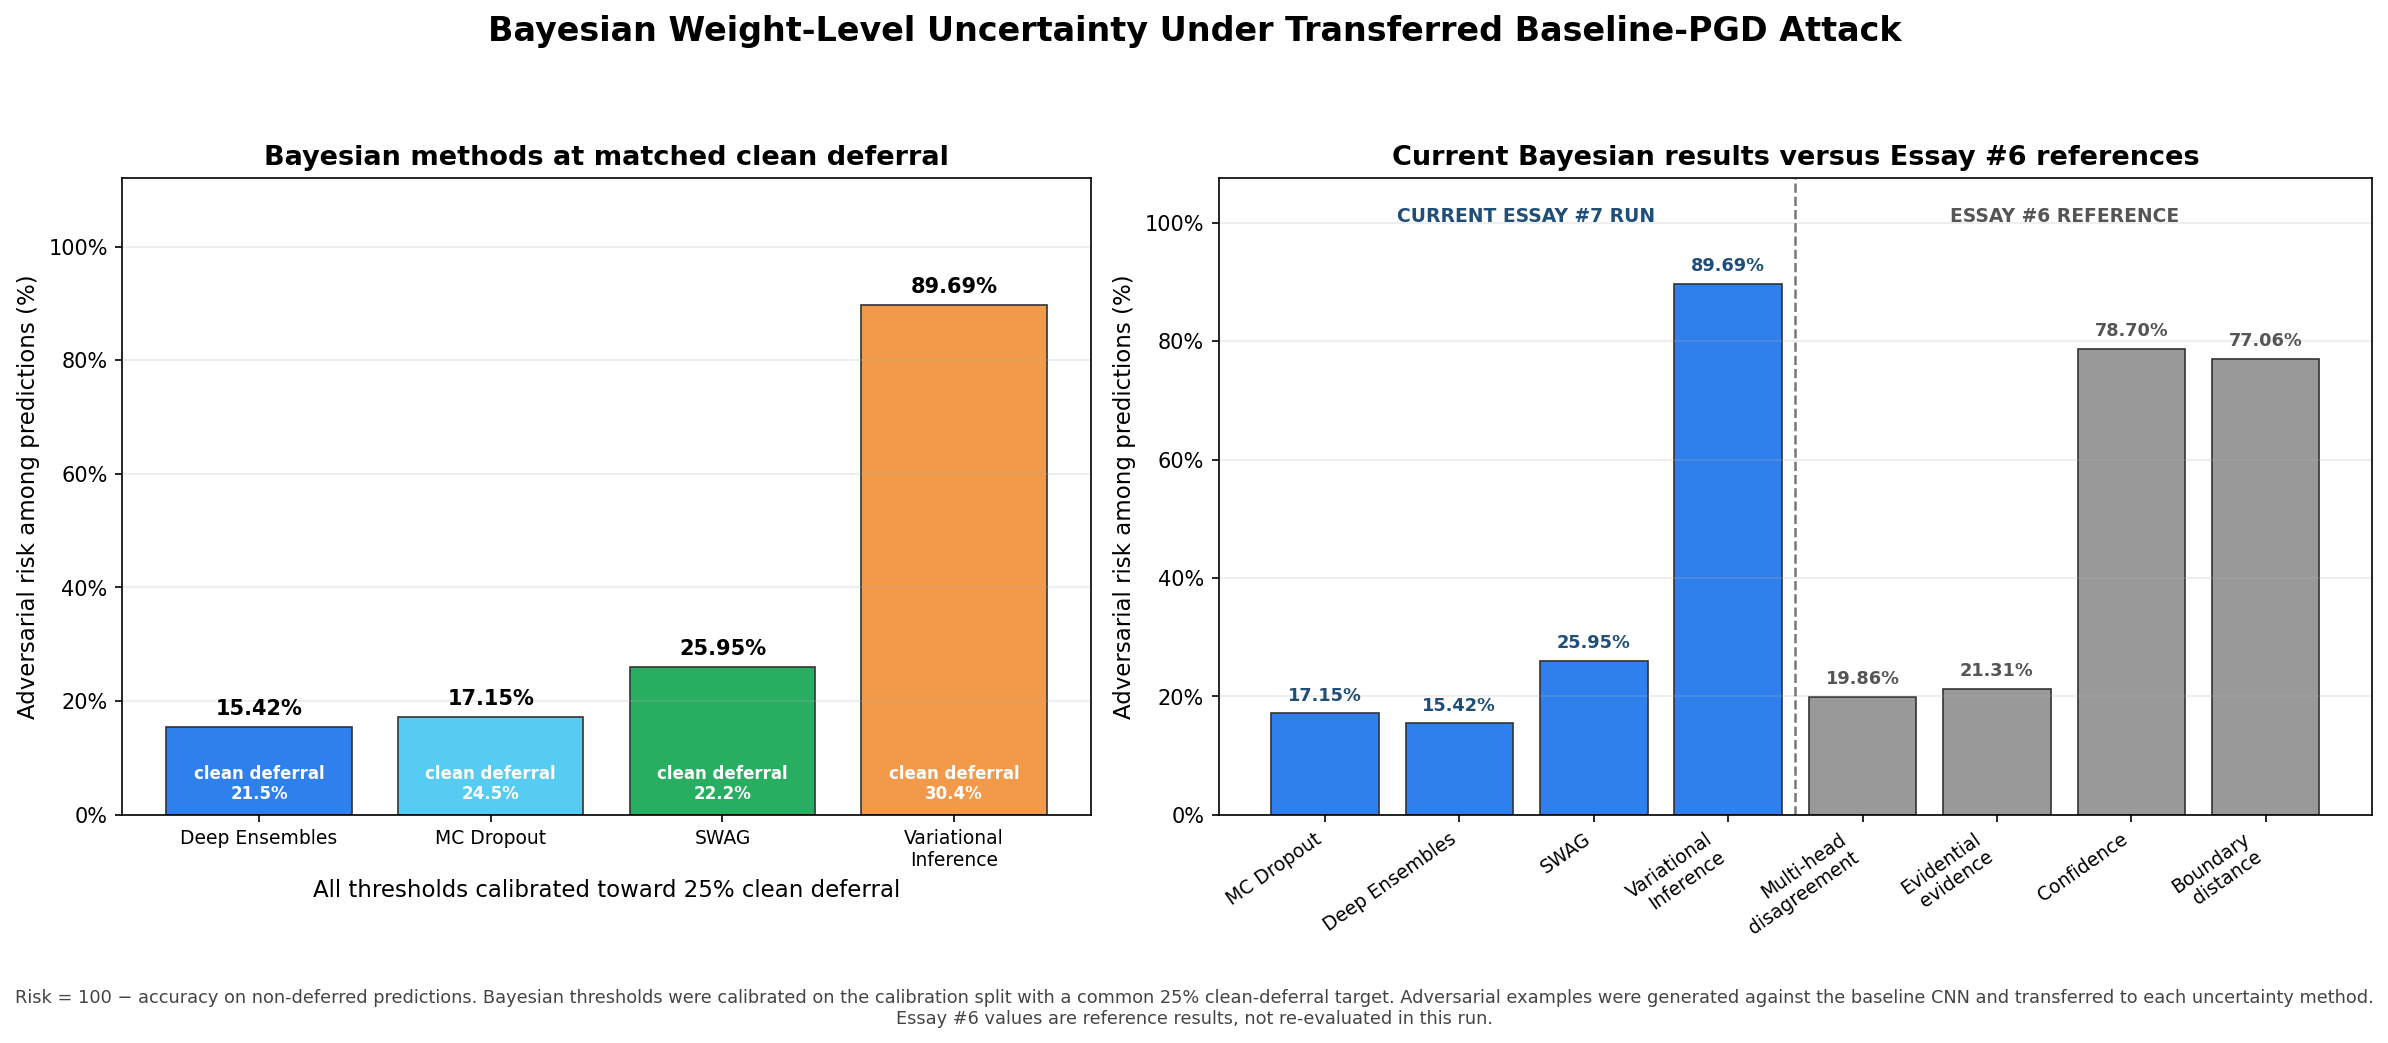


Publication figure saved:
- essay7_bayesian_comparison.png


In [11]:
# =============================================================
# Part J — Calibrated Head-to-Head Comparison
# =============================================================
#
# Evaluation design:
#   1. Calibrate one uncertainty threshold per method
#      using the calibration split only.
#   2. Target the same clean deferral rate for every method.
#   3. Evaluate clean and transferred baseline-PGD data
#      on the untouched evaluation split.
#   4. Risk = 100 - accuracy on non-deferred predictions.
#
# Important:
#   - Attacks are generated against baseline_model.
#   - The attacks are transferred attacks, not adaptive attacks.
#   - Images are normalized, so PGD uses clamp_valid().
# =============================================================

import csv
import json
import math
import time

import numpy as np
import torch
import torch.nn.functional as F


# -------------------------------------------------------------
# 1. Reproducibility and evaluation configuration
# -------------------------------------------------------------

set_seed(42)

TARGET_CLEAN_DEFERRAL = 0.25

PGD_EPSILON = 0.03
PGD_STEP_SIZE = 0.007
PGD_STEPS = 40

MC_PASSES = 50
POSTERIOR_SAMPLES = 30

REPORT_CSV = "essay7_bayesian_comparison.csv"
REPORT_JSON = "essay7_bayesian_comparison.json"


print("=" * 70)
print("Essay #7 — Calibrated Bayesian Uncertainty Comparison")
print("=" * 70)
print(f"Target clean deferral: {TARGET_CLEAN_DEFERRAL * 100:.2f}%")
print(f"PGD epsilon: {PGD_EPSILON}")
print(f"PGD step size: {PGD_STEP_SIZE}")
print(f"PGD steps: {PGD_STEPS}")
print("Attack type: transferred baseline-PGD")
print("Risk definition: 100 - accuracy on non-deferred predictions")
print("=" * 70)


# -------------------------------------------------------------
# 2. Correct PGD implementation for normalized CIFAR-10 images
# -------------------------------------------------------------

def pgd_attack_transferred(
    attack_model,
    images,
    labels,
    epsilon=PGD_EPSILON,
    step_size=PGD_STEP_SIZE,
    num_steps=PGD_STEPS,
):
    """
    Generate transferred PGD examples.

    The attack is optimized against attack_model, normally baseline_model.
    The input images are normalized CIFAR-10 tensors, so the final projection
    uses clamp_valid() rather than torch.clamp(..., 0, 1).
    """
    attack_model.eval()

    original = images.detach().to(DEVICE)
    labels = labels.detach().to(DEVICE)

    adversarial = original.clone().detach()

    for _ in range(num_steps):
        adversarial.requires_grad_(True)

        logits = attack_model(adversarial)
        loss = F.cross_entropy(logits, labels)

        gradient = torch.autograd.grad(
            loss,
            adversarial,
            retain_graph=False,
            create_graph=False,
        )[0]

        updated = adversarial.detach() + step_size * gradient.sign()

        perturbation = torch.clamp(
            updated - original,
            min=-epsilon,
            max=epsilon,
        )

        adversarial = clamp_valid(original + perturbation).detach()

    return adversarial


# -------------------------------------------------------------
# 3. Prediction functions for all four methods
# -------------------------------------------------------------

def predict_mc_dropout(images):
    """
    MC Dropout predictive mean and class-wise variance.
    """
    return mc_dropout_predict(
        mc_model,
        images,
        num_passes=MC_PASSES,
    )


def predict_deep_ensemble(images):
    """
    Deep Ensemble predictive mean and class-wise variance.
    """
    return ensemble_predict(
        ensemble_models,
        images,
    )


def predict_swag(images):
    """
    SWAG predictive mean and class-wise variance.
    """
    return swag_predict(
        swag,
        images,
        num_samples=POSTERIOR_SAMPLES,
    )


def predict_variational_inference(images):
    """
    Variational inference predictive mean and class-wise variance.
    """
    return vi_predict(
        vi_model,
        images,
        num_samples=POSTERIOR_SAMPLES,
    )


METHODS = {
    "MC Dropout": {
        "predict_fn": predict_mc_dropout,
        "cost": "Low",
        "type": "Bayesian approximation",
    },
    "Deep Ensembles": {
        "predict_fn": predict_deep_ensemble,
        "cost": "Medium",
        "type": "Bayesian approximation",
    },
    "SWAG": {
        "predict_fn": predict_swag,
        "cost": "Medium",
        "type": "Bayesian approximation",
    },
    "Variational Inference": {
        "predict_fn": predict_variational_inference,
        "cost": "High",
        "type": "Bayesian approximation",
    },
}


# -------------------------------------------------------------
# 4. Common uncertainty score
# -------------------------------------------------------------

def uncertainty_score_from_variance(variance):
    """
    Common uncertainty score used for the head-to-head comparison.

    variance shape:
        [batch_size, num_classes]

    Score:
        maximum class-probability variance for each image.
    """
    if variance.ndim == 1:
        return variance

    return variance.max(dim=-1).values


# -------------------------------------------------------------
# 5. Collect clean calibration scores
# -------------------------------------------------------------

def collect_calibration_outputs(predict_fn, loader):
    """
    Run one method on the calibration split.

    The calibration split is used only to estimate:
        - uncertainty scores
        - predictions
        - labels

    It is not used for final reporting.
    """
    all_scores = []
    all_predictions = []
    all_labels = []

    predict_start = time.time()

    for batch_index, (images, labels) in enumerate(loader, start=1):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.no_grad():
            mean_pred, variance = predict_fn(images)

        scores = uncertainty_score_from_variance(variance)
        predictions = mean_pred.argmax(dim=-1)

        all_scores.append(scores.detach().cpu())
        all_predictions.append(predictions.detach().cpu())
        all_labels.append(labels.detach().cpu())

        if batch_index % 10 == 0:
            print(
                f"  Calibration batch {batch_index} "
                f"completed in {time.time() - predict_start:.1f}s"
            )

    scores = torch.cat(all_scores).numpy()
    predictions = torch.cat(all_predictions).numpy()
    labels = torch.cat(all_labels).numpy()

    return {
        "scores": scores,
        "predictions": predictions,
        "labels": labels,
    }


# -------------------------------------------------------------
# 6. Calibrate threshold at a fixed clean deferral rate
# -------------------------------------------------------------

def calibrate_threshold(scores, target_deferral):
    """
    Select an uncertainty threshold using calibration scores only.

    Images with score > threshold are deferred.

    The threshold is chosen so that approximately target_deferral
    of the calibration images are deferred.
    """
    if not 0.0 <= target_deferral < 1.0:
        raise ValueError("target_deferral must be in [0, 1).")

    quantile = 1.0 - target_deferral
    threshold = float(np.quantile(scores, quantile))

    calibration_deferred = scores > threshold
    calibration_deferral_rate = float(calibration_deferred.mean())

    return {
        "threshold": threshold,
        "calibration_deferral_rate": calibration_deferral_rate,
        "calibration_coverage": 1.0 - calibration_deferral_rate,
    }


# -------------------------------------------------------------
# 7. Metric calculation
# -------------------------------------------------------------

def calculate_metrics(predictions, labels, scores, threshold):
    """
    Calculate clean or adversarial metrics.

    Deferred predictions are excluded from accuracy and risk.
    """
    deferred = scores > threshold
    predicted_mask = ~deferred

    total = len(labels)
    deferred_count = int(deferred.sum())
    predicted_count = int(predicted_mask.sum())

    deferral_rate = deferred_count / total if total else 0.0
    coverage = predicted_count / total if total else 0.0

    if predicted_count > 0:
        correct_count = int(
            (predictions[predicted_mask] == labels[predicted_mask]).sum()
        )
        accuracy = correct_count / predicted_count
        risk = 1.0 - accuracy
    else:
        correct_count = 0
        accuracy = 0.0
        risk = 0.0

    return {
        "total": total,
        "predicted": predicted_count,
        "deferred": deferred_count,
        "correct_on_predicted": correct_count,
        "accuracy_on_predicted": accuracy * 100.0,
        "risk_on_predicted": risk * 100.0,
        "coverage": coverage * 100.0,
        "deferral_rate": deferral_rate * 100.0,
        "threshold": float(threshold),
    }


# -------------------------------------------------------------
# 8. Evaluate one method on a loader
# -------------------------------------------------------------

def evaluate_method(
    method_name,
    predict_fn,
    loader,
    threshold,
    attack=False,
):
    """
    Evaluate one method on clean or transferred adversarial data.

    If attack=True, adversarial images are generated against baseline_model
    and then evaluated using the selected uncertainty method.
    """
    all_predictions = []
    all_labels = []
    all_scores = []

    evaluation_start = time.time()

    for batch_index, (images, labels) in enumerate(loader, start=1):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if attack:
            images = pgd_attack_transferred(
                attack_model=baseline_model,
                images=images,
                labels=labels,
            )

        with torch.no_grad():
            mean_pred, variance = predict_fn(images)

        scores = uncertainty_score_from_variance(variance)
        predictions = mean_pred.argmax(dim=-1)

        all_predictions.append(predictions.detach().cpu())
        all_labels.append(labels.detach().cpu())
        all_scores.append(scores.detach().cpu())

        if batch_index % 20 == 0:
            condition = "adversarial" if attack else "clean"
            print(
                f"  {method_name} | {condition} | "
                f"batch {batch_index} | "
                f"elapsed {time.time() - evaluation_start:.1f}s"
            )

    predictions = torch.cat(all_predictions).numpy()
    labels = torch.cat(all_labels).numpy()
    scores = torch.cat(all_scores).numpy()

    return calculate_metrics(
        predictions=predictions,
        labels=labels,
        scores=scores,
        threshold=threshold,
    )


# -------------------------------------------------------------
# 9. Evaluate the baseline without deferral
# -------------------------------------------------------------

def evaluate_baseline_without_deferral(loader, attack=False):
    """
    Evaluate the baseline CNN without deferral.

    This is included as a reference row. It is not a Bayesian method.
    """
    all_predictions = []
    all_labels = []

    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        if attack:
            images = pgd_attack_transferred(
                attack_model=baseline_model,
                images=images,
                labels=labels,
            )

        with torch.no_grad():
            logits = baseline_model(images)
            predictions = logits.argmax(dim=-1)

        all_predictions.append(predictions.detach().cpu())
        all_labels.append(labels.detach().cpu())

    predictions = torch.cat(all_predictions).numpy()
    labels = torch.cat(all_labels).numpy()

    accuracy = float((predictions == labels).mean() * 100.0)

    return {
        "total": len(labels),
        "predicted": len(labels),
        "deferred": 0,
        "correct_on_predicted": int((predictions == labels).sum()),
        "accuracy_on_predicted": accuracy,
        "risk_on_predicted": 100.0 - accuracy,
        "coverage": 100.0,
        "deferral_rate": 0.0,
        "threshold": None,
    }


# -------------------------------------------------------------
# 10. Calibrate all methods
# -------------------------------------------------------------

calibration_results = {}
thresholds = {}

print("\n" + "=" * 70)
print("STEP 1 — Calibration on the calibration split")
print("=" * 70)

for method_name, method_config in METHODS.items():
    print(f"\nCalibrating: {method_name}")

    calibration_outputs = collect_calibration_outputs(
        predict_fn=method_config["predict_fn"],
        loader=calib_loader,
    )

    calibration_info = calibrate_threshold(
        scores=calibration_outputs["scores"],
        target_deferral=TARGET_CLEAN_DEFERRAL,
    )

    threshold = calibration_info["threshold"]
    thresholds[method_name] = threshold

    calibration_results[method_name] = {
        **calibration_info,
        "number_of_samples": len(calibration_outputs["scores"]),
        "uncertainty_min": float(calibration_outputs["scores"].min()),
        "uncertainty_max": float(calibration_outputs["scores"].max()),
        "uncertainty_mean": float(calibration_outputs["scores"].mean()),
    }

    print(f"  Threshold: {threshold:.8f}")
    print(
        "  Calibration deferral: "
        f"{calibration_info['calibration_deferral_rate'] * 100:.2f}%"
    )
    print(
        "  Calibration coverage: "
        f"{calibration_info['calibration_coverage'] * 100:.2f}%"
    )


# -------------------------------------------------------------
# 11. Evaluate all methods on clean and adversarial data
# -------------------------------------------------------------

comparison_results = {}

print("\n" + "=" * 70)
print("STEP 2 — Evaluation on the untouched evaluation split")
print("=" * 70)

for method_name, method_config in METHODS.items():
    print(f"\nEvaluating: {method_name}")

    threshold = thresholds[method_name]
    predict_fn = method_config["predict_fn"]

    clean_metrics = evaluate_method(
        method_name=method_name,
        predict_fn=predict_fn,
        loader=eval_loader,
        threshold=threshold,
        attack=False,
    )

    print(f"\n  {method_name} — CLEAN")
    print(
        f"    Accuracy on predicted: "
        f"{clean_metrics['accuracy_on_predicted']:.2f}%"
    )
    print(f"    Clean risk: {clean_metrics['risk_on_predicted']:.2f}%")
    print(f"    Clean coverage: {clean_metrics['coverage']:.2f}%")
    print(f"    Clean deferral: {clean_metrics['deferral_rate']:.2f}%")

    adversarial_metrics = evaluate_method(
        method_name=method_name,
        predict_fn=predict_fn,
        loader=eval_loader,
        threshold=threshold,
        attack=True,
    )

    print(f"\n  {method_name} — TRANSFERRED BASELINE-PGD")
    print(
        f"    Accuracy on predicted: "
        f"{adversarial_metrics['accuracy_on_predicted']:.2f}%"
    )
    print(
        f"    Adversarial risk: "
        f"{adversarial_metrics['risk_on_predicted']:.2f}%"
    )
    print(
        f"    Adversarial coverage: "
        f"{adversarial_metrics['coverage']:.2f}%"
    )
    print(
        f"    Adversarial deferral: "
        f"{adversarial_metrics['deferral_rate']:.2f}%"
    )

    comparison_results[method_name] = {
        "type": method_config["type"],
        "cost": method_config["cost"],
        "threshold": threshold,
        "calibration": calibration_results[method_name],
        "clean": clean_metrics,
        "adversarial": adversarial_metrics,
    }


# -------------------------------------------------------------
# 12. Baseline reference evaluation
# -------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 3 — Baseline reference")
print("=" * 70)

baseline_clean = evaluate_baseline_without_deferral(
    loader=eval_loader,
    attack=False,
)

print("\nBaseline — CLEAN")
print(f"  Accuracy: {baseline_clean['accuracy_on_predicted']:.2f}%")
print(f"  Risk: {baseline_clean['risk_on_predicted']:.2f}%")

baseline_adversarial = evaluate_baseline_without_deferral(
    loader=eval_loader,
    attack=True,
)

print("\nBaseline — TRANSFERRED BASELINE-PGD")
print(f"  Accuracy: {baseline_adversarial['accuracy_on_predicted']:.2f}%")
print(f"  Risk: {baseline_adversarial['risk_on_predicted']:.2f}%")


# -------------------------------------------------------------
# 13. Clean comparison table
# -------------------------------------------------------------

def print_comparison_table(comparison_results):
    headers = [
        "Method",
        "Threshold",
        "Clean Acc.",
        "Clean Risk",
        "Clean Cov.",
        "Clean Def.",
        "Adv. Acc.",
        "Adv. Risk",
        "Adv. Cov.",
        "Adv. Def.",
        "Cost",
    ]

    rows = []

    for method_name, result in comparison_results.items():
        clean = result["clean"]
        adversarial = result["adversarial"]

        rows.append(
            [
                method_name,
                f"{result['threshold']:.8f}",
                f"{clean['accuracy_on_predicted']:.2f}%",
                f"{clean['risk_on_predicted']:.2f}%",
                f"{clean['coverage']:.2f}%",
                f"{clean['deferral_rate']:.2f}%",
                f"{adversarial['accuracy_on_predicted']:.2f}%",
                f"{adversarial['risk_on_predicted']:.2f}%",
                f"{adversarial['coverage']:.2f}%",
                f"{adversarial['deferral_rate']:.2f}%",
                result["cost"],
            ]
        )

    widths = [
        max(len(headers[i]), *(len(row[i]) for row in rows))
        for i in range(len(headers))
    ]

    separator = "-+-".join("-" * width for width in widths)

    print("\n" + "=" * 70)
    print("FINAL BAYESIAN COMPARISON")
    print("=" * 70)

    print(" | ".join(headers[i].ljust(widths[i]) for i in range(len(headers))))
    print(separator)

    for row in rows:
        print(" | ".join(row[i].ljust(widths[i]) for i in range(len(row))))


print_comparison_table(comparison_results)


# -------------------------------------------------------------
# 14. Comparison against the approved Essay #6 values
# -------------------------------------------------------------

essay6_reference = {
    "Multi-head disagreement": {
        "type": "Architecture-native",
        "adversarial_risk": 19.86,
        "cost": "Medium",
    },
    "Evidential evidence": {
        "type": "Architecture-native",
        "adversarial_risk": 21.31,
        "cost": "Medium",
    },
    "Confidence": {
        "type": "Output-level baseline",
        "adversarial_risk": 78.70,
        "cost": "Low",
    },
    "Boundary distance": {
        "type": "Geometric signal",
        "adversarial_risk": 77.06,
        "cost": "Medium",
    },
}


print("\n" + "=" * 70)
print("COMPARISON AGAINST ESSAY #6")
print("=" * 70)

reference_headers = [
    "Method",
    "Type",
    "Adversarial Risk",
    "Cost",
]

reference_rows = []

for method_name, reference in essay6_reference.items():
    reference_rows.append(
        [
            method_name,
            reference["type"],
            f"{reference['adversarial_risk']:.2f}%",
            reference["cost"],
        ]
    )

for method_name, result in comparison_results.items():
    reference_rows.append(
        [
            method_name,
            result["type"],
            f"{result['adversarial']['risk_on_predicted']:.2f}%",
            result["cost"],
        ]
    )
    reference_widths = [
      max(
        len(reference_headers[i]),
        *(len(row[i]) for row in reference_rows),
    )
    for i in range(len(reference_headers))
    ]

reference_separator = "-+-".join("-" * width for width in reference_widths)

print(
    " | ".join(
        reference_headers[i].ljust(reference_widths[i])
        for i in range(len(reference_headers))
    )
)
print(reference_separator)

for row in reference_rows:
    print(
        " | ".join(
            row[i].ljust(reference_widths[i])
            for i in range(len(row))
        )
    )


# -------------------------------------------------------------
# 15. Determine the best Bayesian method by adversarial risk
# -------------------------------------------------------------

best_method = min(
    comparison_results,
    key=lambda name: comparison_results[name]["adversarial"][
        "risk_on_predicted"
    ],
)

best_result = comparison_results[best_method]
best_risk = best_result["adversarial"]["risk_on_predicted"]

architecture_risks = [
    value["adversarial_risk"]
    for value in essay6_reference.values()
    if value["type"] == "Architecture-native"
]

best_architecture_risk = min(architecture_risks)
difference_from_best_architecture = best_risk - best_architecture_risk

print("\n" + "=" * 70)
print("INTERPRETATION SUMMARY")
print("=" * 70)

print(f"Best Bayesian method by adversarial risk: {best_method}")
print(f"Bayesian adversarial risk: {best_risk:.2f}%")
print(
    "Best Essay #6 architecture-native risk: "
    f"{best_architecture_risk:.2f}%"
)
print(
    "Difference from best architecture-native signal: "
    f"{difference_from_best_architecture:+.2f} percentage points"
)

print("\nImportant interpretation rule:")
print(
    "These results measure risk among non-deferred predictions under "
    "transferred baseline-PGD attack. They do not measure adaptive robustness."
)

# -------------------------------------------------------------
# 16. Publication Figure — Fair Bayesian Comparison
# -------------------------------------------------------------

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


FIGURE_PATH = "essay7_bayesian_comparison.png"


# -------------------------------------------------------------
# Prepare current Bayesian results
# -------------------------------------------------------------

bayesian_names = list(comparison_results.keys())

bayesian_adv_risk = [
    comparison_results[name]["adversarial"]["risk_on_predicted"]
    for name in bayesian_names
]

bayesian_clean_risk = [
    comparison_results[name]["clean"]["risk_on_predicted"]
    for name in bayesian_names
]

bayesian_clean_deferral = [
    comparison_results[name]["clean"]["deferral_rate"]
    for name in bayesian_names
]

bayesian_adv_deferral = [
    comparison_results[name]["adversarial"]["deferral_rate"]
    for name in bayesian_names
]

bayesian_clean_coverage = [
    comparison_results[name]["clean"]["coverage"]
    for name in bayesian_names
]

bayesian_adv_coverage = [
    comparison_results[name]["adversarial"]["coverage"]
    for name in bayesian_names
]


# -------------------------------------------------------------
# Essay #6 reference values
# -------------------------------------------------------------

essay6_names = [
    "Multi-head disagreement",
    "Evidential evidence",
    "Confidence",
    "Boundary distance",
]

essay6_adv_risk = [
    essay6_reference[name]["adversarial_risk"]
    for name in essay6_names
]


# -------------------------------------------------------------
# Plot configuration
# -------------------------------------------------------------

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "legend.fontsize": 9,
        "figure.dpi": 150,
    }
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios": [1.05, 1.25]},
)

fig.suptitle(
    "Bayesian Weight-Level Uncertainty Under Transferred Baseline-PGD Attack",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)


# -------------------------------------------------------------
# Panel A — Fair current Bayesian comparison
# -------------------------------------------------------------

ax = axes[0]

order = np.argsort(bayesian_adv_risk)

ordered_names = [bayesian_names[i] for i in order]
ordered_risks = [bayesian_adv_risk[i] for i in order]
ordered_deferrals = [bayesian_clean_deferral[i] for i in order]

colors = [
    "#2F80ED",
    "#56CCF2",
    "#27AE60",
    "#F2994A",
]

bars = ax.bar(
    range(len(ordered_names)),
    ordered_risks,
    color=[colors[i % len(colors)] for i in range(len(ordered_names))],
    edgecolor="#333333",
    linewidth=0.8,
)

ax.set_title(
    "Bayesian methods at matched clean deferral",
    fontweight="bold",
)

ax.set_ylabel("Adversarial risk among predictions (%)")
ax.set_xlabel(
    "All thresholds calibrated toward "
    f"{TARGET_CLEAN_DEFERRAL * 100:.0f}% clean deferral"
)

ax.set_xticks(range(len(ordered_names)))
ax.set_xticklabels(
    [
        name.replace(" ", "\n", 1)
        if len(name) > 16
        else name
        for name in ordered_names
    ]
)

ax.set_ylim(0, max(100, max(ordered_risks) * 1.25))
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.grid(axis="y", alpha=0.25)

for bar, risk, deferral in zip(
    bars,
    ordered_risks,
    ordered_deferrals,
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{risk:.2f}%",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        2,
        f"clean deferral\n{deferral:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8,
        color="white",
        fontweight="bold",
    )


# -------------------------------------------------------------
# Panel B — Bayesian results and Essay #6 reference
# -------------------------------------------------------------

ax = axes[1]

comparison_names = (
    [
        name.replace(" ", "\n", 1)
        if len(name) > 16
        else name
        for name in bayesian_names
    ]
    + [
        name.replace(" ", "\n", 1)
        if len(name) > 16
        else name
        for name in essay6_names
    ]
)

comparison_risks = bayesian_adv_risk + essay6_adv_risk

x_positions = np.arange(len(comparison_names))

bar_colors = (
    ["#2F80ED"] * len(bayesian_names)
    + ["#999999"] * len(essay6_names)
)

bars = ax.bar(
    x_positions,
    comparison_risks,
    color=bar_colors,
    edgecolor="#333333",
    linewidth=0.8,
)

ax.set_title(
    "Current Bayesian results versus Essay #6 references",
    fontweight="bold",
)

ax.set_ylabel("Adversarial risk among predictions (%)")
ax.set_xticks(x_positions)
ax.set_xticklabels(comparison_names, rotation=35, ha="right")

ax.set_ylim(0, max(100, max(comparison_risks) * 1.20))
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.grid(axis="y", alpha=0.25)

for index, (bar, value) in enumerate(
    zip(bars, comparison_risks)
):
    label_color = "#1F4E79" if index < len(bayesian_names) else "#555555"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold",
        color=label_color,
    )

# Visual separation between current and historical results
reference_start = len(bayesian_names) - 0.5

ax.axvline(
    reference_start,
    color="#555555",
    linestyle="--",
    linewidth=1.2,
    alpha=0.8,
)

ax.text(
    len(bayesian_names) / 2 - 0.5,
    ax.get_ylim()[1] * 0.94,
    "CURRENT ESSAY #7 RUN",
    ha="center",
    va="center",
    fontsize=9,
    fontweight="bold",
    color="#1F4E79",
)

ax.text(
    len(bayesian_names) + len(essay6_names) / 2 - 0.5,
    ax.get_ylim()[1] * 0.94,
    "ESSAY #6 REFERENCE",
    ha="center",
    va="center",
    fontsize=9,
    fontweight="bold",
    color="#555555",
)


# -------------------------------------------------------------
# Figure note
# -------------------------------------------------------------

fig.text(
    0.5,
    0.015,
    (
        "Risk = 100 − accuracy on non-deferred predictions. "
        "Bayesian thresholds were calibrated on the calibration split "
        "with a common 25% clean-deferral target. "
        "Adversarial examples were generated against the baseline CNN "
        "and transferred to each uncertainty method. "
        "Essay #6 values are reference results, not re-evaluated in this run."
    ),
    ha="center",
    va="bottom",
    fontsize=8.5,
    color="#444444",
    wrap=True,
)

plt.tight_layout(rect=[0, 0.08, 1, 0.93])

plt.savefig(
    FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print("\nPublication figure saved:")
print(f"- {FIGURE_PATH}")


In [12]:
# -------------------------------------------------------------
# Part K: Summary and Outputs
# -------------------------------------------------------------

print("\n" + "="*55)
print("Experiment Summary")
print("="*55)

print(f"""
Baseline:
  - Clean accuracy: {clean_acc:.2f}%

MC Dropout:
  - Sanity prediction: {mean_pred.argmax().item()}
  - Sanity confidence: {mean_pred.max().item():.4f}
  - Sanity variance: {variance.max().item():.6f}

Deep Ensembles:
  - Sanity prediction: {mean_pred_ens.argmax().item()}
  - Sanity confidence: {mean_pred_ens.max().item():.4f}
  - Sanity variance: {variance_ens.max().item():.6f}

SWAG:
  - Sanity prediction: {mean_pred_swag.argmax().item()}
  - Sanity confidence: {mean_pred_swag.max().item():.4f}
  - Sanity variance: {variance_swag.max().item():.6f}

Variational Inference:
  - Sanity prediction: {mean_pred_vi.argmax().item()}
  - Sanity confidence: {mean_pred_vi.max().item():.4f}
  - Sanity variance: {variance_vi.max().item():.6f}

Output files:
  - checkpoint_baseline_cifar10.pth
  - checkpoint_mc_dropout.pth
  - checkpoint_ensemble_*.pth
  - checkpoint_swag.pth
  - checkpoint_vi.pth
""")

print("\nNotebook complete!")


Experiment Summary

Baseline:
  - Clean accuracy: 78.61%

MC Dropout:
  - Sanity prediction: 2
  - Sanity confidence: 0.8413
  - Sanity variance: 0.016266

Deep Ensembles:
  - Sanity prediction: 5
  - Sanity confidence: 0.3028
  - Sanity variance: 0.061952

SWAG:
  - Sanity prediction: 4
  - Sanity confidence: 0.4635
  - Sanity variance: 0.062248

Variational Inference:
  - Sanity prediction: 7
  - Sanity confidence: 0.1023
  - Sanity variance: 0.000237

Output files:
  - checkpoint_baseline_cifar10.pth
  - checkpoint_mc_dropout.pth
  - checkpoint_ensemble_*.pth
  - checkpoint_swag.pth
  - checkpoint_vi.pth


Notebook complete!
